In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as pltcol
from scipy import stats
import math
from scipy.stats import mannwhitneyu
import glob
from matplotlib.colors import LinearSegmentedColormap
from collections import Counter
import collections
import cmasher as cmr
import glob
from scipy.stats import ttest_ind
import statsmodels.stats.multitest as multi
import numpy as np
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.graphics.api import abline_plot
from scipy import stats
import xgboost
from sklearn.metrics import explained_variance_score
from sklearn.metrics import max_error
from xgboost import plot_importance
from scipy.stats import gaussian_kde
from scipy.stats import ttest_rel

In [ ]:
#data for model

d_tables_drivers = {}
om_tables_drivers = {}
d_tables_drivers_contr = {}
om_tables_drivers_contr = {}
ds_types = ['country', 'state', 'city']
countries = ['UnitedKingdom','Switzerland', 'Netherlands', 'Croatia', 'Poland', 'Romania', 'Norway', 'Sweden', 'Spain', 'Russia','Italy', 'Slovakia', 'Germany',  'Ireland','Austria', 'Portugal','CzechRepublic',  'France', 'Greece','Turkey',  'UnitedArabEmirates', 'SouthKorea', 'Japan', 'Malaysia','Thailand','SriLanka', 'Nigeria', 'Brazil','Colombia', 'Argentina','Chile','Mexico']

for ds_type in ds_types:
    files = glob.glob(ds_type+'/*'+ds_type+'*_Ranks_RoundedHLA.csv')
    names = set([i.split('_')[2] for i in files])
    print(names)
    for name in names:
        if (name not in d_tables_drivers.keys())&(name in countries):
            d_tables_drivers[name] = pd.read_csv(ds_type+'/Delta_' + name + '_drivers_full_Ranks_RoundedHLA.csv', dtype={'Allele frequency': str}, index_col = False)
            d_tables_drivers[name]['country'] = name
            d_tables_drivers[name] = d_tables_drivers[name][~d_tables_drivers[name]['Allele Name'].str.startswith('HLA-C')]
            om_tables_drivers[name] = pd.read_csv(ds_type+'/Omicron_' +name + '_drivers_full_Ranks_RoundedHLA.csv', dtype={'Allele frequency': str}, index_col = False)
            om_tables_drivers[name]['country'] = name
            om_tables_drivers[name] = om_tables_drivers[name][~om_tables_drivers[name]['Allele Name'].str.startswith('HLA-C')]
            d_tables_drivers_contr[name] = pd.read_csv(ds_type+'/Delta_' +name + '_driversCONTRsTRONG15_full_Ranks_RoundedHLA_breakFiltered.csv', dtype={'Allele frequency': str}, index_col = False)
            d_tables_drivers_contr[name] = d_tables_drivers_contr[name][~d_tables_drivers_contr[name]['Allele Name'].str.startswith('HLA-C')]
            d_tables_drivers_contr[name]['country'] = name
            om_tables_drivers_contr[name] = pd.read_csv(ds_type+'/Omicron_' +name + '_driversCONTRsTRONG15_full_Ranks_RoundedHLA_breakFiltered.csv', dtype={'Allele frequency': str}, index_col = False)        
            om_tables_drivers_contr[name] = om_tables_drivers_contr[name][~om_tables_drivers_contr[name]['Allele Name'].str.startswith('HLA-C')]
            om_tables_drivers_contr[name]['country'] = name
d_tables_drivers['World'] = pd.read_csv('Delta_gisaid_drivers_full_Ranks_RoundedHLA.csv', dtype={'Allele frequency': str}, index_col = False)
d_tables_drivers['World']['country'] = 'World'
d_tables_drivers['World'] = d_tables_drivers['World'][~d_tables_drivers['World']['Allele Name'].str.startswith('HLA-C')]
om_tables_drivers['World'] = pd.read_csv('Omicron_gisaid_drivers_full_Ranks_RoundedHLA.csv', dtype={'Allele frequency': str}, index_col = False)
om_tables_drivers['World']['country'] = 'World'
om_tables_drivers['World'] = om_tables_drivers['World'][~om_tables_drivers['World']['Allele Name'].str.startswith('HLA-C')]
d_tables_drivers_contr['World'] = pd.read_csv('Delta_gisaid_driversCONTRsTRONG15_full_Ranks_RoundedHLA_breakFiltered.csv', dtype={'Allele frequency': str}, index_col = False)
d_tables_drivers_contr['World'] = d_tables_drivers_contr['World'][~d_tables_drivers_contr['World']['Allele Name'].str.startswith('HLA-C')]
d_tables_drivers_contr['World']['country'] = 'World'
om_tables_drivers_contr['World'] = pd.read_csv('Omicron_gisaid_driversCONTRsTRONG15_full_Ranks_RoundedHLA_breakFiltered.csv', dtype={'Allele frequency': str}, index_col = False)        
om_tables_drivers_contr['World'] = om_tables_drivers_contr['World'][~om_tables_drivers_contr['World']['Allele Name'].str.startswith('HLA-C')]
om_tables_drivers_contr['World']['country'] = 'World'

immun1 = pd.read_csv('tcell_table_export_1701167238.csv', header=[0,1])
immun2 = pd.read_csv('tcell_table_export_1701167293.csv', header=[0,1])
immun3 = pd.read_csv('tcell_table_export_1701167144.csv', header=[0,1])
immun_I = pd.concat([immun1, immun2, immun3])
immun_I.columns = [c[0] + "_" + c[1] for c in immun_I.columns]
immun_I = immun_I[['Epitope_Name', 'MHC Restriction_Name', 'Assay_Qualitative Measurement']].drop_duplicates().rename(columns = {'Epitope_Name':
                                                'peptide', 'MHC Restriction_Name':'Allele Name', 'Assay_Qualitative Measurement':'Assay_Qualitative'})[['peptide','Allele Name', 'Assay_Qualitative']].fillna(0)

immun_I = immun_I[(immun_I['peptide'].str.len() <13) & (immun_I['peptide'].str.len() >7)&(immun_I['Allele Name'].str.contains(':'))]
immun_I = immun_I[(~immun_I['Allele Name'].str.startswith('HLA-D'))].drop_duplicates()
immun_I['Allele Name'] = immun_I['Allele Name'].str.replace('*', '')

immun1 = pd.read_csv('epitope_table_export_1704710003.csv')
immun2 = pd.read_csv('epitope_table_export_1704710037.csv')
immun3 = pd.read_csv('epitope_table_export_1704710067.csv')
immun_ep = pd.concat([immun1, immun2, immun3]).rename(columns = {'Epitopes - Epitope':'peptide'})

immun_final = pd.merge(immun_I, immun_ep, on = 'peptide', how = 'left').drop_duplicates()


from pard.grantham import grantham

ds = {}
oms = {}
ds_c = {}
oms_c = {}
def make_ok_df(table1, name,effect):
    print(name)
    #print(all_all[all_all['peptide'] == 'NIADYNYKL'].shape)
    #print(table1[table1['wt_EL_Rank'].isna()].shape)
    table = pd.merge(table1, all_all[['prot_name', 'peptide', 'Allele Name','mutations', 'wt_EL_Rank', 'mut_EL_Rank', 'country']], left_on =['prot_name', 'peptide', 'Allele Name', 'driver_mut_total', 'country'],
                    right_on =['prot_name', 'peptide', 'Allele Name', 'mutations', 'country'], how = 'left')
    #print(table[table['wt_EL_Rank'].isna()].shape)
    table['EL_rank'] = table['mut_EL_Rank'] / table['wt_EL_Rank']
    table['country'] = name
    table['EV_binding'] = effect#'Lost binding'
    table['end'] = [i + len(j) for i, j in zip(table['begin'], table['peptide'])]
    
    table['AAsubs'] = [i[0] + i[-1] for i in table['driver_mut_total']]
    table['grantham'] = [grantham(i[0],i[-1]) for i in table['AAsubs']]
    table = pd.merge(table,  immun_final[['peptide', 'Epitopes - # References', 
        'Epitopes - # Assays']], on = ['peptide'], how = 'left').drop_duplicates(['driver_mut_total', 'Allele Name', 'peptide', 'prot_name']).rename(columns = {
        'Epitopes - # References':'ep_num_ref','Epitopes - # Assays':'ep_num_ass'})
    #print(table[table['wt_EL_Rank'].isna()].shape)
    return table

for name in countries:
    ds[name] = make_ok_df(d_tables_drivers[name],name, 'Lost binding')
    oms[name] = make_ok_df(om_tables_drivers[name], name,'Lost binding')
    
    ds_c[name] = make_ok_df(d_tables_drivers_contr[name],name, 'Increased binding')
    #print(d_tables_drivers_contr[name][d_tables_drivers_contr[name]['peptide'] == 'NIADYNYKL'].shape)
    oms_c[name] = make_ok_df(om_tables_drivers_contr[name], name,'Increased binding')
    
    

d_tables_drivers_all = pd.concat(ds.values())[['country', 'prot_name', 'peptide', 'begin','end', 'driver_mut_total', 'EV_binding','fraction_total', 'Allele Name', 'driver_mut_occurrences_total','Allele frequency_total', 'grantham', 'wt_EL_Rank', 'mut_EL_Rank', 'EL_rank','ep_num_ref', 'ep_num_ass']]
d_tables_drivers_contr_all = pd.concat(ds_c.values())[['country', 'prot_name', 'peptide', 'begin','end', 'driver_mut_total', 'EV_binding','fraction_total','driver_mut_occurrences_total', 'Allele Name', 'Allele frequency_total', 'grantham', 'wt_EL_Rank', 'mut_EL_Rank', 'EL_rank','ep_num_ref', 'ep_num_ass']]
d_tables_drivers_all_all = pd.concat([d_tables_drivers_all, d_tables_drivers_contr_all]).rename(columns = {'driver_mut_total':'driver_mutation', 'fraction_total':'driver_fraction', 'driver_mut_occurrences_total':'driver_occurrences', 'Allele frequency_total':'HLA allele frequency'})
d_tables_drivers_all_all.to_csv('model/All_countries_drivers_Delta_model.csv',index = False)
om_tables_drivers_all = pd.concat(oms.values())[['country','prot_name', 'peptide', 'begin', 'end','driver_mut_total', 'EV_binding', 'fraction_total','driver_mut_occurrences_total','Allele Name', 'Allele frequency_total', 'grantham', 'wt_EL_Rank', 'mut_EL_Rank', 'EL_rank','ep_num_ref', 'ep_num_ass']]
om_tables_drivers_contr_all = pd.concat(oms_c.values())[['country', 'prot_name', 'peptide', 'begin','end', 'driver_mut_total', 'EV_binding','fraction_total', 'driver_mut_occurrences_total','Allele Name', 'Allele frequency_total', 'grantham', 'wt_EL_Rank', 'mut_EL_Rank', 'EL_rank','ep_num_ref', 'ep_num_ass']]
om_tables_drivers_all_all = pd.concat([om_tables_drivers_all, om_tables_drivers_contr_all]).rename(columns = {'driver_mut_total':'driver_mutation', 'fraction_total':'driver_fraction', 'driver_mut_occurrences_total':'driver_occurrences', 'Allele frequency_total':'HLA allele frequency'})
om_tables_drivers_all_all.to_csv('model/All_countries_drivers_Omicron_model.csv',index = False)

In [ ]:
#example of script for cluster that was used for XGboost model
#here is an example for Delta, loss drivers. Overall 4 models were trained: for Delta and Omicron, loss and increase drivers

import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import pandas as pd
import xgboost
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.model_selection import RandomizedSearchCV

delta = pd.read_csv('All_countries_drivers_Delta_model.csv')
#delta = pd.read_csv('All_countries_drivers_Omicron_model.csv') for omicron
delta_loss = delta[delta['EV_binding'] == 'Lost binding']
#= delta[delta['EV_binding'] == 'Increased binding'] for increase drivers

delta_loss['sequences_total'] = delta_loss['driver_occurrences'] / delta_loss['driver_fraction'] 
y = delta_loss[['driver_fraction']]
X1 = delta_loss.drop(['driver_fraction', 'driver_occurrences','EL_rank','Allele Name',
                     'driver_mutation','begin', 'end','EV_binding'], axis=1)
check_prot = X1['prot_name'].value_counts().reset_index()
X1['prot_to_strat'] = [i if check_prot[check_prot['prot_name'] == i]['count'].values[0]>150 else 'rare' for i in X1['prot_name']]
check_c = X1['country'].value_counts().reset_index()
X1['country_to_strat'] = [i if check_c[check_c['country'] == i]['count'].values[0]>400 else 'rare' for i in X1['country']]
check_pept = X1['peptide'].value_counts().reset_index()
X1['pept_to_strat'] = [i if check_pept[check_pept['peptide'] == i]['count'].values[0]>100 else 'rare' for i in X1['peptide']]

X_prot = pd.get_dummies(X1['prot_name'])
X_country = pd.get_dummies(X1['country'])
X_peptide = pd.get_dummies(X1['peptide'])

X = pd.concat([X1, X_prot, X_country, X_peptide], axis = 1).drop(['prot_name', 'country', 'peptide'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state=7, stratify=X[['prot_to_strat', 'country_to_strat','pept_to_strat']])
X_train = X_train.drop(columns=['prot_to_strat', 'country_to_strat','pept_to_strat'])
X_test = X_test.drop(columns=['prot_to_strat', 'country_to_strat','pept_to_strat'])


max_depth = [5,6, 7, 10, 13, 15,20]
min_child_weight = [0.5, 0.7,0.8,1, 3, 5,7]
colsample_bytree = np.linspace(0.1, 1, 5)
subsample = np.linspace(0.1, 1, 5)

random_grid = {'n_estimators': [50,60,75,100,150, 200,350, 500,700, 800, 1000],
               'max_depth': max_depth,
               'min_child_weight': min_child_weight,
               'learning_rate':[0.05],'colsample_bytree':colsample_bytree, 
               'subsample':subsample, 'gamma':[0]}

xgb = xgboost.XGBRegressor()
xgb_random = RandomizedSearchCV(estimator = xgb, param_distributions = random_grid, n_iter = 1000, cv = 5, scoring = 'neg_mean_squared_error',verbose=2, random_state=42, n_jobs = -1)# Fit the random search model
xgb_random.fit(X_train, y_train)

print(xgb_random.best_params_)
print(xgb_random.best_estimator_)

best_loss = xgb_random.best_estimator_
best_loss.fit(X_train, y_train)
best_loss_train = best_loss.predict(X_train)
best_loss_test = best_loss.predict(X_test)
df = pd.DataFrame({'type':['train' for i in range(len(y_train['driver_fraction']))] + ['test' for i in range(len(y_test))],
                   'true':list(y_train['driver_fraction'].values)+list(y_test['driver_fraction'].values), 
                 'predict':list(best_loss_train) + list(best_loss_test)})
df.to_csv('model/Delta_loss_modelWithPept_stratifiedMSEiter1000_results.csv')

In [4]:
delta = pd.read_csv('model/All_countries_drivers_Delta_model.csv')
delta_loss = delta[delta['EV_binding'] == 'Lost binding']
delta_loss = delta_loss.rename(columns = {'HLA allele frequency':'HLA allele\nfrequency'})
delta_loss = delta_loss.rename(columns = {'wt_EL_Rank':'wt affinity'})
delta_loss = delta_loss.rename(columns = {'mut_EL_Rank':'mut affinity'})

delta_loss['# sequences'] = delta_loss['driver_occurrences'] / delta_loss['driver_fraction'] 
y = delta_loss[['driver_fraction']]
X1 = delta_loss.drop(['driver_fraction', 'driver_occurrences','EL_rank','Allele Name',
                     'driver_mutation','begin', 'end','EV_binding'], axis=1)
check_prot = X1['prot_name'].value_counts().reset_index()
X1['prot_to_strat'] = [i if check_prot[check_prot['index'] == i]['prot_name'].values[0]>150 else 'rare' for i in X1['prot_name']]
check_c = X1['country'].value_counts().reset_index()
X1['country_to_strat'] = [i if check_c[check_c['index'] == i]['country'].values[0]>400 else 'rare' for i in X1['country']]
check_pept = X1['peptide'].value_counts().reset_index()
X1['pept_to_strat'] = [i if check_pept[check_pept['index'] == i]['peptide'].values[0]>100 else 'rare' for i in X1['peptide']]

X_prot = pd.get_dummies(X1['prot_name'])
X_country = pd.get_dummies(X1['country'])
X_peptide = pd.get_dummies(X1['peptide'])
X = pd.concat([X1, X_prot, X_country, X_peptide], axis = 1).drop(['prot_name', 'country', 'peptide'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state=7, stratify=X[['prot_to_strat', 'country_to_strat', 'pept_to_strat']])
X_train = X_train.drop(columns=['prot_to_strat', 'country_to_strat', 'pept_to_strat'])
X_test = X_test.drop(columns=['prot_to_strat', 'country_to_strat', 'pept_to_strat'])

In [8]:
delta = pd.read_csv('model/Delta_loss_modelWithPept_stratifiedMSEiter1000_results.csv', index_col = 0)
y_train = delta[delta['type'] == 'train']['true']
y_test = delta[delta['type'] == 'test']['true']
y_train_pred = delta[delta['type'] == 'train']['predict']
y_test_pred = delta[delta['type'] == 'test']['predict']

mse1 = mean_squared_error(y_test, y_test_pred)
print(f'Mean Squared Error: {mse1}')
mae = mean_absolute_error(y_test, y_test_pred)
print(f'Mean Abs Error: {mae}')
r2_1 = r2_score(y_test, y_test_pred)
print(f'R-squared: {r2_1}')

print('\nExpected:')
aver = np.mean(y_test)
mse2 = mean_squared_error(y_test, [aver for i in y_test])
print(f'Mean Squared Error: {mse2}')
mae = mean_absolute_error(y_test, [aver for i in y_test])
print(f'Mean Abs Error: {mae}')
r2_2 = r2_score(y_test, [aver for i in y_test])
print(f'R-squared: {r2_2}')

print(f'MSE model / MSE expected: {mse1/mse2}')

Mean Squared Error: 0.00016706903998318007
Mean Abs Error: 0.0013190082439655307
R-squared: 0.034189114304866375

Expected:
Mean Squared Error: 0.00017298318175709278
Mean Abs Error: 0.001622777875227823
R-squared: 0.0
MSE model / MSE expected: 0.9658108856951336


In [9]:
#{'subsample': 0.325, 'n_estimators': 50, 'min_child_weight': 7, 'max_depth': 20, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 1.0}
best_loss = xgboost.XGBRegressor(subsample = 0.325, n_estimators = 50, min_child_weight = 7, max_depth=20, 
                                   learning_rate= 0.05, gamma= 0, 
                                    colsample_bytree= 1,random_state=42)
best_loss.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
             device=None, early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=0, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=20,
             max_leaves=None, min_child_weight=7, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=50,
             n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [10]:
import shap
shap.initjs()
X_sampled = X_train.sample(14000, random_state=10)
explainer = shap.Explainer(best_loss, algorithm='tree')
shap_values = explainer(X_sampled)

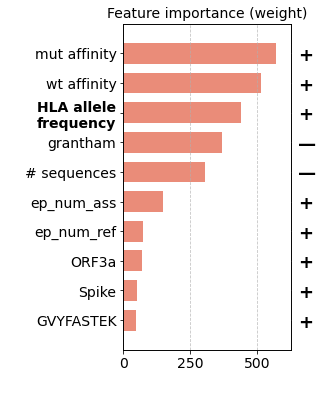

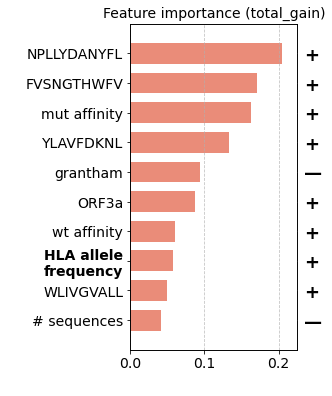

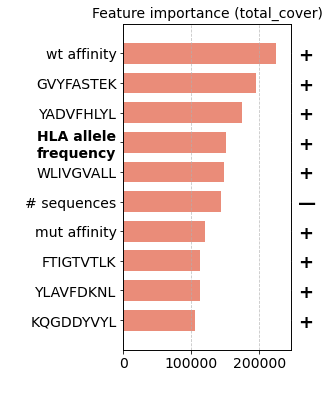

In [13]:
for col in ['weight', 'total_gain', 'total_cover']:
    colors = cmr.take_cmap_colors('coolwarm', 20, return_fmt='hex')
    palette = [colors[16]]

    fig, ax = plt.subplots(figsize = (3,6))
    plot_importance(best_loss, ax=ax,importance_type = col, max_num_features=10, height = 0.7, show_values = False, color = palette,
                       alpha=0.8)

    #sns.barplot(x='index', y='feature', data=all_imp_top, alpha =0.8, color = colors[16], saturation=1,
    #                ax=ax, orient = 'h', order = all_imp_top['feature'])
    ax.set_title('Feature importance ('+col+')', fontsize=14)
    #ax.set_xticks([0,0.0015,0.003])
    plt.grid(axis='y', linestyle='--', alpha=0)
    plt.grid(axis='x', linestyle='--', alpha=0.75)
    ax.tick_params(axis = 'both', labelsize=14)
    ax.set_xlabel(' ', fontsize=14)
    ax.set_ylabel(' ', fontsize=14)
    for lab in ax.get_yticklabels():
        if lab.get_text() == "HLA allele\nfrequency":
            lab.set_fontweight('bold')
    #plt.savefig('Omicron_feature_importance_SUM.jpg', dpi=300, bbox_inches='tight')
    #ax.set_xticks([0,500, 1000, 1500])


    feats = [item.get_text() for item in ax.get_yticklabels(which='both')][::-1]
    signs = []
    for i in feats:
        x = shap_values[:, i].data
        y = shap_values[:, i].values
        rho, pval = stats.spearmanr(x,y)
        if pval<0.05:
            if rho<0:
                signs.append('—')
            else:
                signs.append('+')
        else:
            signs.append(' ')
    ax2 = ax.twinx()
    #
    ymin, ymax = ax.get_ylim()
    # apply function and set transformed values to right axis limits
    ax2.set_ylim(ymin,ymax)
    ax2.set_yticks(np.arange(0,10,1))

    ax2.tick_params(axis = 'both', labelsize=18,color = 'white')# weight = 'bold')
    ax2.set_yticklabels(signs[::-1], weight='bold')

    #plt.savefig('Delta_'+col+'_short.jpg', dpi=300, bbox_inches='tight')